# Querying the RUL benchmark suite

One API over all benchmarks (`src/rulbench/datasets.py`):

```python
units, meta = datasets.load(name, fd=1, split="dev", **kwargs)
```

Everything auto-downloads on first load and is cached afterwards
(`~/.rul-datasets`, `~/.rulbench`):

| dataset | download | on disk (cached) |
|---|---|---|
| cmapss | 12 MB | 47 MB |
| ncmapss | **15.8 GB** (single archive, all sub-datasets) | 29 GB |
| femto | 0.8 GB | 3.6 GB |
| xjtu | 5.4 GB | 16 GB |
| milling | 15 MB | 98 MB |
| phme20 | 1 MB | 5.3 MB |

Every dataset comes back as a **list of `Unit` objects, one per run-to-failure trajectory**:

| field | shape | meaning |
|---|---|---|
| `Unit.features` | `(T, L, C)` | T degradation steps, each an L-sample snapshot over C channels |
| `Unit.rul` | `(T,)` | remaining useful life at each step, in the dataset's native time unit |
| `Unit.censored` | bool | True: run ends by observation cutoff, `rul` is a lower bound, not the true RUL |

The *container* is identical everywhere; the *content* is not — what one step is, the
channels, the time unit, and whether RUL is capped all differ per dataset:

| dataset | one step is | L | C | rul unit | cap |
|---|---|---|---|---|---|
| cmapss | sliding 30-cycle window | 30 | 14 | flight cycles | 125 |
| ncmapss | one flight cycle | ~20k (raw), less with `resolution_seconds` | 32 | flight cycles | 65 |
| femto | 0.1 s vibration burst | 2560 | 2 | bursts (~10 s apart) | - |
| xjtu | 1.28 s vibration burst | 32768 | 2 | bursts (~1 min apart) | - |
| milling | one cut | varies per case | 6 | cuts | - |
| phme20 | one 10 Hz reading | 1 | 3 | seconds | - |

`ims` raises until a labeling convention is adopted (it ships no labels). `phme20` is an
extra loader, not part of the six-benchmark suite. Scaling caveat: the four
rul-datasets-backed benchmarks arrive **library-scaled** (cmapss MinMax(-1,1),
ncmapss MinMax(0,1), femto/xjtu z-scored — fitted on the dev split), while milling and
phme20 are **raw physical units**. Model adapters should therefore renormalize from the
context; see the closing notes.

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.exceptions import InconsistentVersionWarning

from rulbench import datasets

# stale ~/.rul-datasets scaler pickles (sklearn version drift); delete the .pkl files to refit
warnings.filterwarnings("ignore", category=InconsistentVersionWarning)

## Quickstart: one benchmark

In [2]:
units, meta = datasets.load("cmapss", fd=1, split="dev")
u = units[0]
print(f"{len(units)} units | first unit: {u.unit_id}")
print(f"features {u.features.shape} (T, L, C) | rul {u.rul.shape}, "
      f"{u.rul.max():.0f} -> {u.rul.min():.0f} {meta['time_unit']}s | censored={u.censored}")
meta

80 units | first unit: cmapss-fd1-dev-000
features (163, 30, 14) (T, L, C) | rul (163,), 125 -> 1 flight cycles | censored=False


{'time_unit': 'flight cycle',
 'channels': '14 of 21 sensors (Ragab selection)',
 'rul_cap': 125,
 'step': 'sliding window over cycles (stride 1); test split = last window only',
 'fd': 1,
 'split': 'dev'}

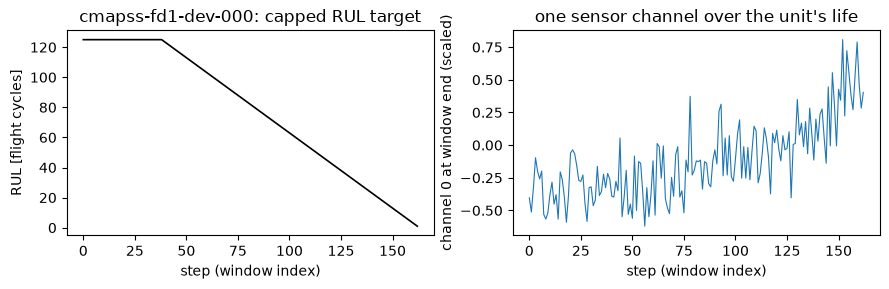

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3))
ax1.plot(u.rul, color="black", lw=1.2)
ax1.set_xlabel("step (window index)")
ax1.set_ylabel(f"RUL [{meta['time_unit']}s]")
ax1.set_title(f"{u.unit_id}: capped RUL target")
ax2.plot(u.features[:, -1, 0], lw=0.8)
ax2.set_xlabel("step (window index)")
ax2.set_ylabel("channel 0 at window end (scaled)")
ax2.set_title("one sensor channel over the unit's life")
fig.tight_layout()

## Suite overview

N-CMAPSS is loaded at 60 s resolution here to keep windows small.

In [4]:
SUITE = [
    ("cmapss", dict(fd=1)),
    ("ncmapss", dict(fd=2, resolution_seconds=60)),
    ("femto", dict(fd=1)),
    ("xjtu", dict(fd=1)),
    ("milling", dict()),
    ("phme20", dict(fd=1)),
]

rows = []
for name, kw in SUITE:
    units, meta = datasets.load(name, **kw)
    Ts = [len(x.rul) for x in units]
    Ls = sorted({x.features.shape[1] for x in units})
    rows.append({
        "dataset": name,
        "fd": meta.get("fd", "-"),
        "units": len(units),
        "T (min-max)": f"{min(Ts)}-{max(Ts)}",
        "L": str(Ls[0]) if len(Ls) == 1 else f"{Ls[0]}-{Ls[-1]}",
        "C": units[0].features.shape[2],
        "time unit": meta["time_unit"],
        "rul cap": meta["rul_cap"],
    })
pd.DataFrame(rows).set_index("dataset")

  warnings.warn(


,fd,units,T (min-max),L,C,time unit,rul cap
dataset,,,,,,,
cmapss,1,80,99-333,30,14,flight cycle,125.0
ncmapss,2,5,63-89,451,32,flight cycle,65.0
femto,1,2,871-2803,2560,2,burst (~10 s apart),NaN
xjtu,1,2,123-161,32768,2,burst (~1 min apart),NaN
milling,-,15,5-19,9000,6,cut,NaN
phme20,1,12,2343-2776,1,3,second (10 Hz sampling),NaN


## Censoring

Milling and PHME20 construct RUL from a threshold crossing (interpolated VB >= 0.45 mm,
pressure drop > 20 psi). Runs that never cross are **censored**: their true RUL is
unknown, only a lower bound. They are dropped by default; `include_censored=True` keeps
them with `Unit.censored = True`. With the current thresholds no real run is censored —
but the milling threshold choice directly controls this (case 7 peaks at VB 0.46).

In [5]:
for name, kw in [("milling", dict()), ("phme20", dict(fd=1, split="dev"))]:
    units, meta = datasets.load(name, include_censored=True, **kw)
    n_cens = sum(x.censored for x in units)
    print(f"{name}: {len(units)} units, {n_cens} censored | target: {meta['target']}")

milling: 15 units, 0 censored | target: cuts until interpolated VB >= 0.45 mm
phme20: 12 units, 0 censored | target: seconds until pressure drop first exceeds 20.0 psi


## Context/query pattern for zero-shot evaluation

Zero-shot evaluation = labeled **context** units in, predictions for **query** units
out. C-MAPSS test units carry a single trailing window each (the classic protocol:
predict RUL at the last observed cycle). Swap `y_pred` for a model adapter
(flattened windows for TabPFN, raw sequences for the xLSTM-PFN).

In [6]:
ctx_units, _ = datasets.load("cmapss", fd=1, split="dev")
query_units, _ = datasets.load("cmapss", fd=1, split="test")

y_true = np.array([x.rul[-1] for x in query_units])
y_pred = np.full(len(query_units), np.mean(np.concatenate([x.rul for x in ctx_units])))
print(f"{len(query_units)} test engines, true RUL {y_true.min():.0f}-{y_true.max():.0f} cycles "
      f"| context-mean prediction: {y_pred[0]:.1f}")

100 test engines, true RUL 7-125 cycles | context-mean prediction: 80.2


## Notes for model adapters

- **Normalize from the context, in the adapter.** Upstream scaling is inconsistent by
  construction (three library conventions + two raw loaders). Fitting per-channel
  statistics on the context units and applying them to context + query makes every
  benchmark uniform and absorbs the library's affine transforms.
- **Do not stack units.** T varies per unit everywhere, L varies within milling —
  windowing/padding is the adapter's job (e.g. Theiler-style flatten for TabPFN).
- **Respect capping when comparing across datasets.** cmapss/ncmapss RUL is a capped
  piecewise-linear target; the other four count down from a real event.
- `datasets.load("ims")` raises until a labeling convention is decided.